## Instabilité d'un jet de Bickley dans le modèle QG barotrope
Equations : 
$$
\begin{align}
&q = \left(\frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2}\right) \psi +\beta y \\
&\frac{\partial q}{\partial t} + \mathrm{J}\left( \psi, q\right) = 0
\end{align}
$$

Ici, $x\in [0, 2\pi]$ et $y\in[-1, 1]$. Le champ de vitesse initial est de la forme :
$$
U(x, y) = U_0 \mathrm{sech}^2{\frac{y}{\alpha}} = U_0\frac{1}{\cosh^2{\frac{y}{\alpha}} }
$$
Ici, on prends $\alpha = 0.5$. Les CLs sur $\psi$ sont :
$$
\begin{align}
&\text{Periodiques selon x}\\
&\psi(x, -1, t) = \psi(x, 1, t) = 0
\end{align}
$$

D'après le critère de Rayleigh, le jet est instable si le gradient de PV change de signe sur le domaine : 
$$
\beta - \frac{\mathrm{d}^2 U}{\mathrm{d}y^2} = 0
$$

In [18]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

#print(ROOT)
#print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

Text(0, 0.5, 'y')

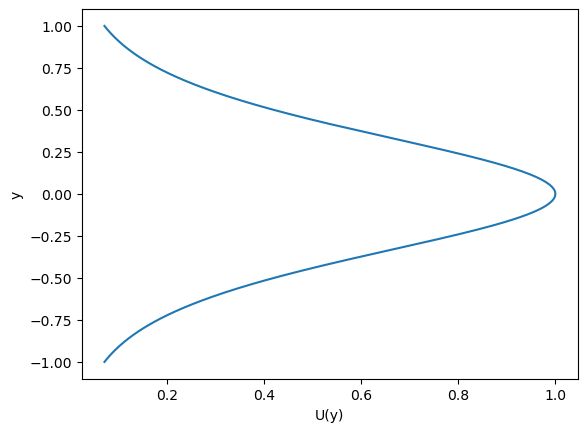

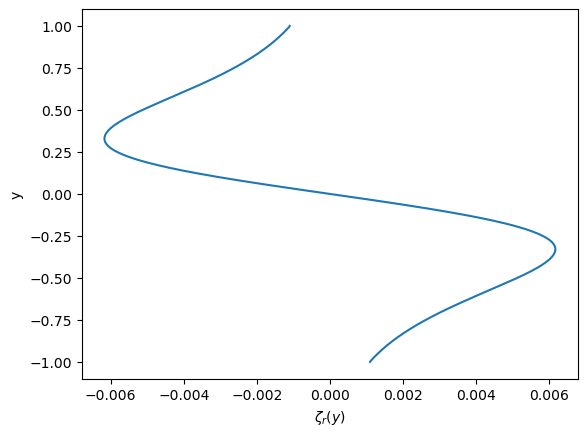

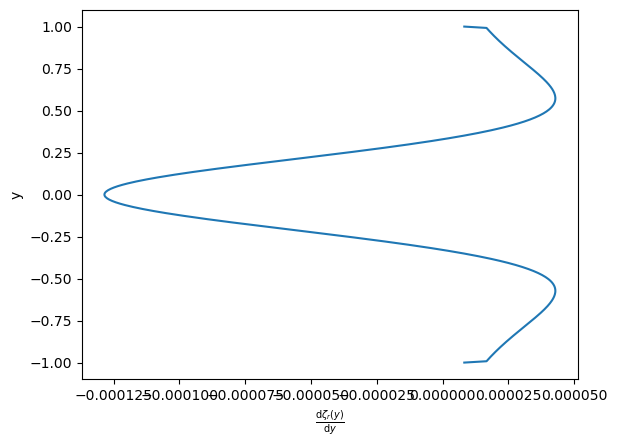

In [10]:
N_points = 500
x_lin = np.linspace(0.0, 2.0*np.pi,N_points, endpoint = False)
y_lin = np.linspace(-1.0, 1.0, N_points)

def BickleyJet(y, alpha, U0=1.0):
    "Jet de Bickley, de largeur gamma et de valeur max U0 (en y=0)"
    return U0*(np.cosh(y/alpha))**(-2.0)

U = BickleyJet(y_lin, 0.5)

vort = np.gradient(U)
grad_vort = np.gradient(vort)

fig = plt.figure()
plt.plot(U, y_lin)
plt.xlabel('U(y)')
plt.ylabel('y')

fig = plt.figure()
plt.plot(vort, y_lin)
plt.xlabel(f"$\zeta_r(y)$")
plt.ylabel('y')

fig = plt.figure()
plt.plot(grad_vort, y_lin)
plt.xlabel(r"$\frac{\mathrm{d}\zeta_r(y)}{\mathrm{d}y}$")
plt.ylabel('y')

## Test code ``Bickley_BT_Test.py``

In [6]:
import xarray as xr
import os
import IPython.display as ipd
repertoire_courant = os.getcwd()
print(repertoire_courant)

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\Test_Bickley_BT


In [7]:
#Permets de charger le contenu du fichier en mémoire.
Ds_his = xr.load_dataset(repertoire_courant + r"//test_bickley//test_bickley_his.nc")
Ds_his.close()

Ds_diags = xr.load_dataset(repertoire_courant + r"//test_bickley//test_bickley_diags.nc")

ipd.display(Ds_his)
ipd.display(Ds_diags)

<xarray.Dataset> Size: 63MB
Dimensions:    (t: 40, x: 256, y: 256)
Coordinates:
  * t          (t) float64 320B 0.05006 0.1 0.15 0.2 ... 1.85 1.9 1.95 2.0
  * x          (x) float64 2kB 0.0 0.02454 0.04909 0.07363 ... 6.21 6.234 6.259
  * y          (y) float64 2kB 1.0 0.9999 0.9997 0.9993 ... -0.9997 -0.9999 -1.0
Data variables:
    psi        (t, x, y) float64 21MB 0.0 -6.919e-05 ... -6.413e-06 0.0
    vorticity  (t, x, y) float64 21MB 1.228 0.8649 0.371 ... 0.5602 0.07983
    PV         (t, x, y) float64 21MB 9.105 0.5909 0.3448 ... 0.7886 0.04797
Attributes: (12/29)
    title:                  test_bickley_his.nc
    Nx:                     256
    Ny:                     256
    x_bounds:               [0.         6.28318531]
    y_bounds:               [-1.  1.]
    list_geometry:          ['basin', 'biperiodic', 'zonal_channel']
    ...                     ...
    dealias_exp_alpha:      100.0
    dealias_exp_p:          8.0
    Model:                  BarotropicQG
    beta:                   0.0
    inv_Rd2:                0.0
    T_0:                    0.0

<xarray.Dataset> Size: 2kB
Dimensions:           (t: 42)
Coordinates:
  * t                 (t) float64 336B 0.0 0.0 0.05006 0.1 ... 1.85 1.9 1.95 2.0
Data variables:
    kinetic_energy    (t) float64 336B 1.158 1.158 1.158 ... 1.158 1.158 1.158
    potential_energy  (t) float64 336B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    total_energy      (t) float64 336B 1.158 1.158 1.158 ... 1.158 1.158 1.158
    PV_total          (t) float64 336B 6.281 6.281 6.281 ... 6.281 6.281 6.281
    enstrophy         (t) float64 336B 8.75 8.75 8.75 8.75 ... 8.781 8.783 8.785
Attributes: (12/29)
    title:                  test_bickley_diags.nc
    Nx:                     256
    Ny:                     256
    x_bounds:               [0.         6.28318531]
    y_bounds:               [-1.  1.]
    list_geometry:          ['basin', 'biperiodic', 'zonal_channel']
    ...                     ...
    dealias_exp_alpha:      100.0
    dealias_exp_p:          8.0
    Model:                  BarotropicQG
    beta:                   0.0
    inv_Rd2:                0.0
    T_0:                    0.0

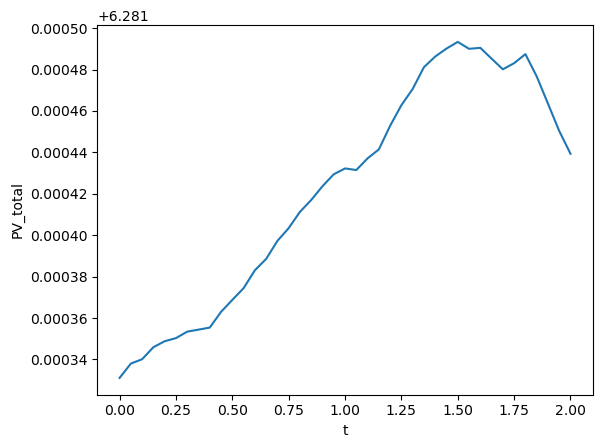

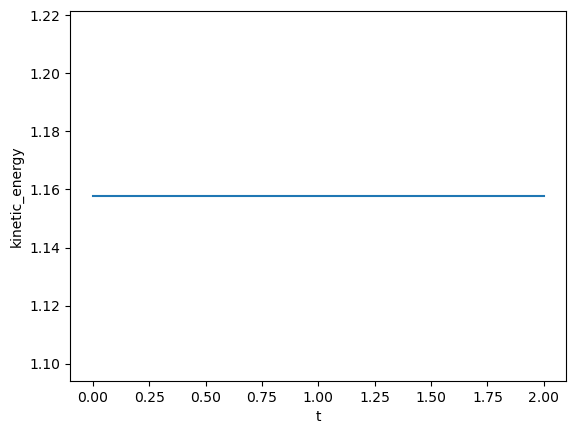

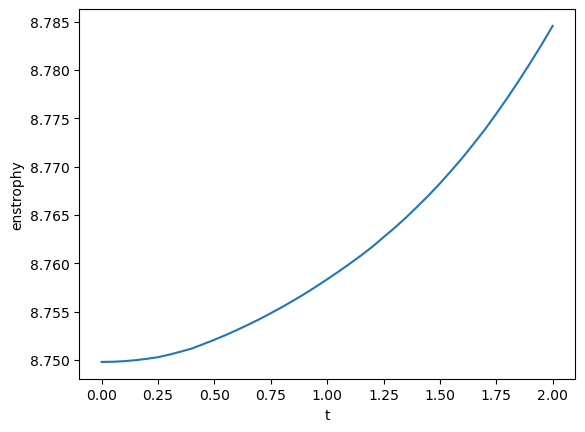

In [24]:
fig = plt.figure()
Ds_diags['PV_total'].plot()
plt.savefig('PV_total_exp_1.png')


fig = plt.figure()
Ds_diags['kinetic_energy'].plot()
plt.savefig('KE_total_exp_1.png')


fig = plt.figure()
Ds_diags['enstrophy'].plot()
plt.savefig('Enstr_total_exp_1.png')

<Figure size 640x480 with 0 Axes>

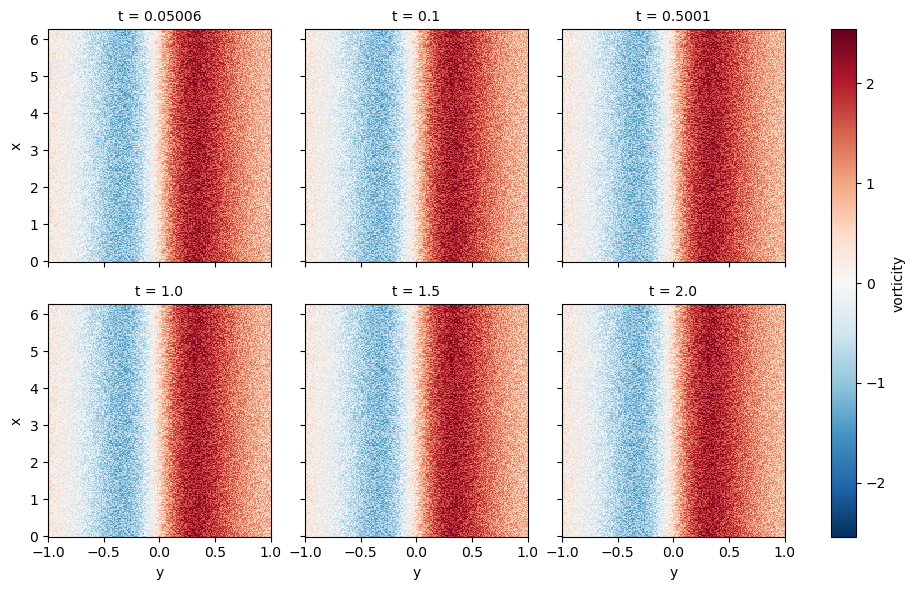

In [25]:
liste_t = [0.05, 0.1, 0.5, 1.0, 1.5, 2.0]

fig = plt.figure()
Ds_his['vorticity'].sel(t=liste_t, method = 'nearest').plot.pcolormesh(col = 't', col_wrap = 3)
plt.savefig('vort_snap_exp_1.png')

In [20]:
import post_processing as ps

In [22]:
ps.animate(Ds_his['vorticity'], regular_grid = False)

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=39, width=550)